# Imports and Paths

In [1]:
import glob
import os 
import xarray as xr
import pandas as pd
import numpy as np
import datetime as dt
from shared_plotting import *
import dask.distributed as dd
import matplotlib.dates as mdates

In [2]:
def add_legend(
    ax,
    handles="None",
    labels="None",
    ncols=None,
    loc=None,
    bbox_to_anchor=None,
    title=None,
    handlelength=0,
):

    if handles != "None":
        leg = ax.legend(
            handles=handles,
            labels=labels,
            ncols=ncols,
            loc=loc,
            bbox_to_anchor=bbox_to_anchor,
            title=title,
            handlelength=handlelength,
        )
    else:
        leg = ax.legend(
            bbox_to_anchor=bbox_to_anchor,
        )

    handles, labels = leg.axes.get_legend_handles_labels()
    texts = leg.get_texts()

    for (
        h,
        text,
    ) in zip(handles, texts):
        try:
            text.set_color(h.get_facecolor()[0])
        except:
            text.set_color(h.get_color())

Now setting up dask for parallel file reading

In [3]:
client = dd.Client('snowfall1:8786')
client

# To see the daskboard, on my terminal the command is:  ssh -L 1111:snowfall1:8787 snowfall1
# then you can go to localhost:1111/status

<Client: 'tcp://172.16.1.236:8786' processes=20 threads=40, memory=300.00 GiB>

In [4]:
figPath = '/squall/gleung/borneolcc-figures/seb/'

# The script dask_calculate_energybudget calculates the terms of the energy budget and puts them in this folder
tempPath = '/squall/gleung/borneolcc-analysis/seb/'

anaPath = '/squall/gleung/borneolcc-analysis/processed/seb/'

In [5]:
runs = ['lc1960','lc2019']

# Energy Budget (All Land Points)

## Preprocess dask output

We need to stitch together the output from dask_calculate_energybudget.py

In [6]:
for run in runs:
    print(run)
    ds = xr.open_mfdataset(sorted(glob.glob(f"{tempPath}/seb_land_{run}_rte_*.nc")), 
                        combine='nested',concat_dim='time',
                        chunks='auto',parallel=True, #dask for efficiency
                        )
    
    # compute net values
    ds = ds.assign({"swnet": ds.swdn - ds.swup, "lwnet": ds.lwdn - ds.lwup})

    # compute heat storage
    ds = ds.assign(
            g=ds.swnet + ds.lwnet - (ds.shf + ds.lhf)
        ) 

    
    # convert to local time
    ds = ds.assign_coords(
        local_time=(
            "time",
            [
                pd.to_datetime(t) + dt.timedelta(hours=8)
                for t in ds.t.values
            ],
        )
    )

    ds = ds.sortby('local_time')

    # remove model spinup
    ds = ds.where(ds.t >= pd.to_datetime("2019-09-16 20:00")).compute().dropna(dim='time',how='all')

    print(ds.t[0].values, ds.t[-1].values)

    # write output for full timeseries of SEB
    ds.to_netcdf(
        f"{anaPath}/timeseries_land_{run}.h5",
        engine="h5netcdf",
        mode="w",
    )

    # calculate the diurnal cycle
    diurn = ds.groupby(ds.local_time.dt.hour)
    
    diurn.mean().to_netcdf(
        f"{anaPath}/diurn_land_{run}.h5",
        engine="h5netcdf",
        mode="w",
    )

    (1.96 * diurn.std()/np.sqrt(diurn.count())).to_netcdf(
        f"{anaPath}/diurn_stde_land_{run}.h5",
        engine="h5netcdf",
        mode="w",
    )

lc1960
2019-09-16T20:00:00.000000000 2019-09-21T20:00:00.000000000
lc2019
2019-09-16T20:00:00.000000000 2019-09-21T20:00:00.000000000


## Full timeseries

### Actual values

lc1960
lc2019


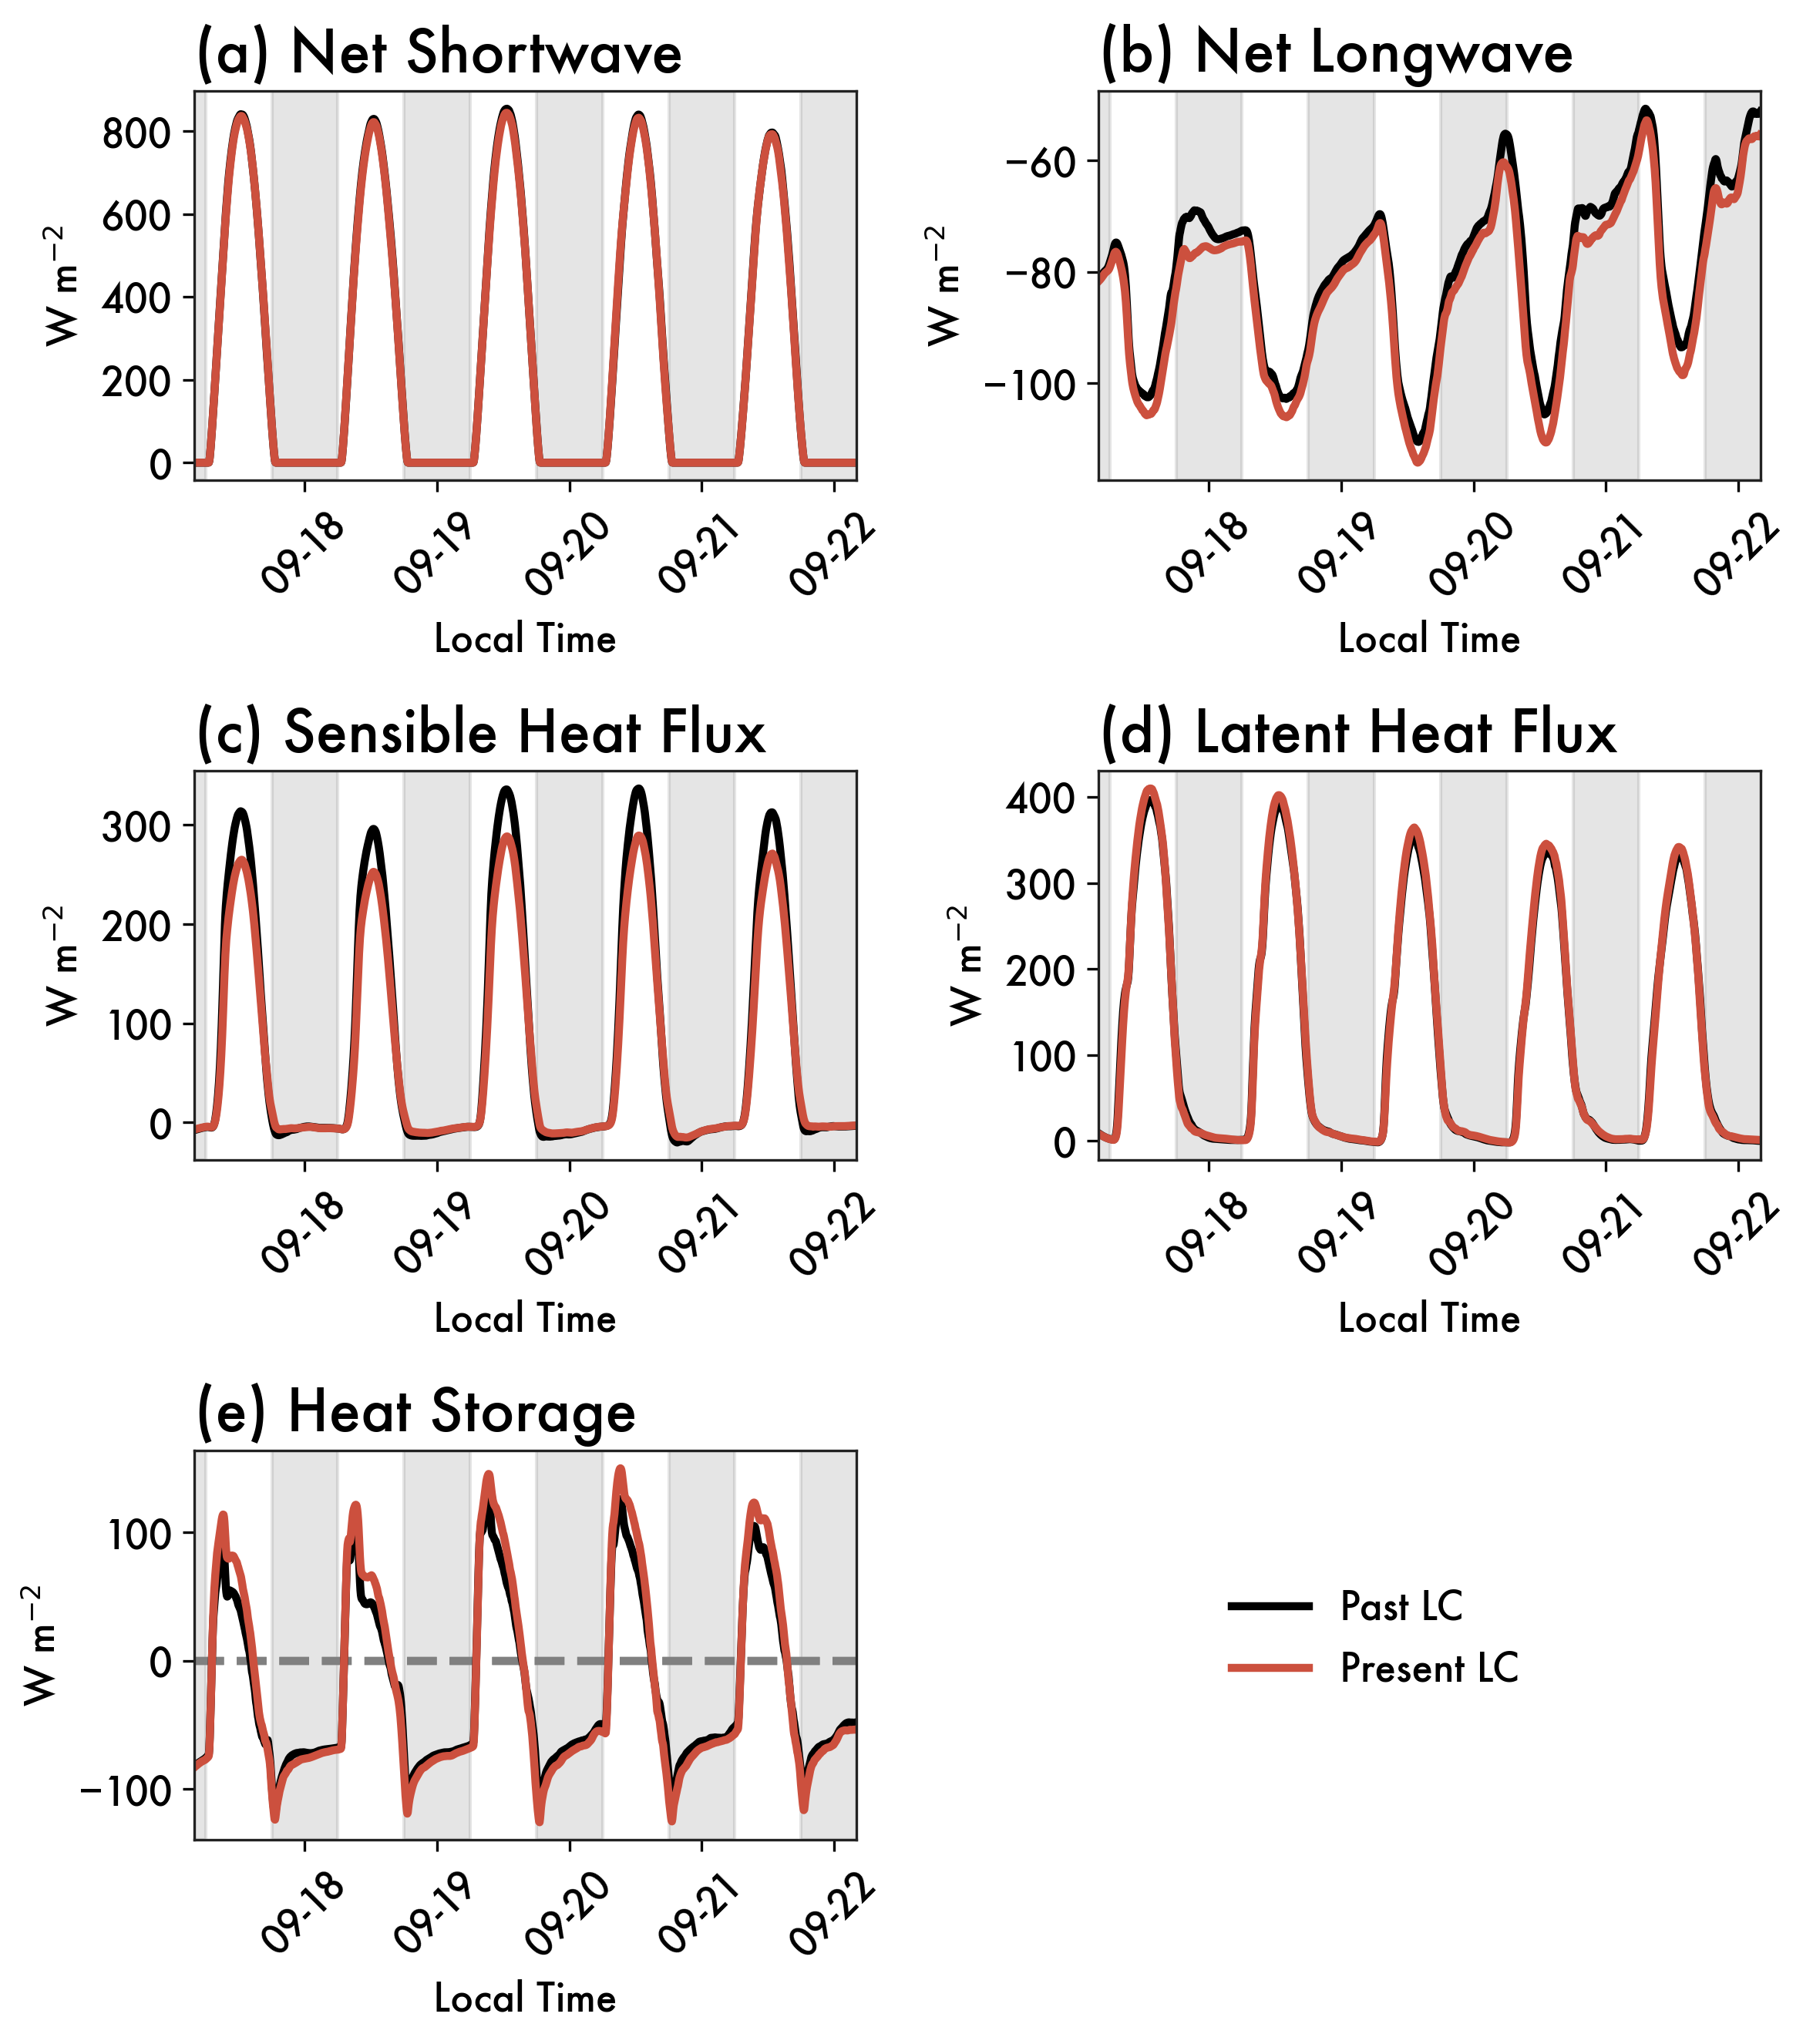

In [67]:
fig,axes=plt.subplots(3,2,figsize=(8,9))
axes = axes.flatten()


for run,col,lab in zip(runs,['black',red],["Past LC","Present LC"]):
    print(run)
    seb = xr.open_dataset(f"{anaPath}/timeseries_land_{run}.h5")
    
    for ax, var in zip(axes, ['swnet','lwnet','shf','lhf','g']):
        ax.plot(seb.local_time,seb[var],color=col,label=lab)

        if var == "g":
            ax.axhline(0, ls="--", color="gray", zorder=0)

    seb.close()

for ax, title in zip(axes, ['(a) Net Shortwave','(b) Net Longwave','(c) Sensible Heat Flux','(d) Latent Heat Flux','(e) Heat Storage']):
    ax.set_title(title)
    ax.set_ylabel('W m$^{-2}$')
    ax.set_xlabel('Local Time')
    ax.tick_params(axis="x", labelrotation=45)

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

    for d in ['2019-09-16',"2019-09-17", "2019-09-18", "2019-09-19", "2019-09-20",'2019-09-21']:
        ax.axvspan(
            pd.to_datetime(f"{d} 18:00"),
            pd.to_datetime(f"{d} 06:00")+dt.timedelta(days=1),
            zorder=0,
            color="gray",
            alpha=0.2,
        )

    ax.set_xlim(pd.to_datetime('2019-09-17 04:00'),pd.to_datetime('2019-09-22 04:00'))

axes[-1].axis("off")

handles, labels = axes[-2].get_legend_handles_labels()
fig.legend(handles, labels,bbox_to_anchor=(0.85,0.245))


plt.savefig(f"{figPath}/seb_timeseries_all.pdf")
plt.show()
plt.close('all')

### Differences

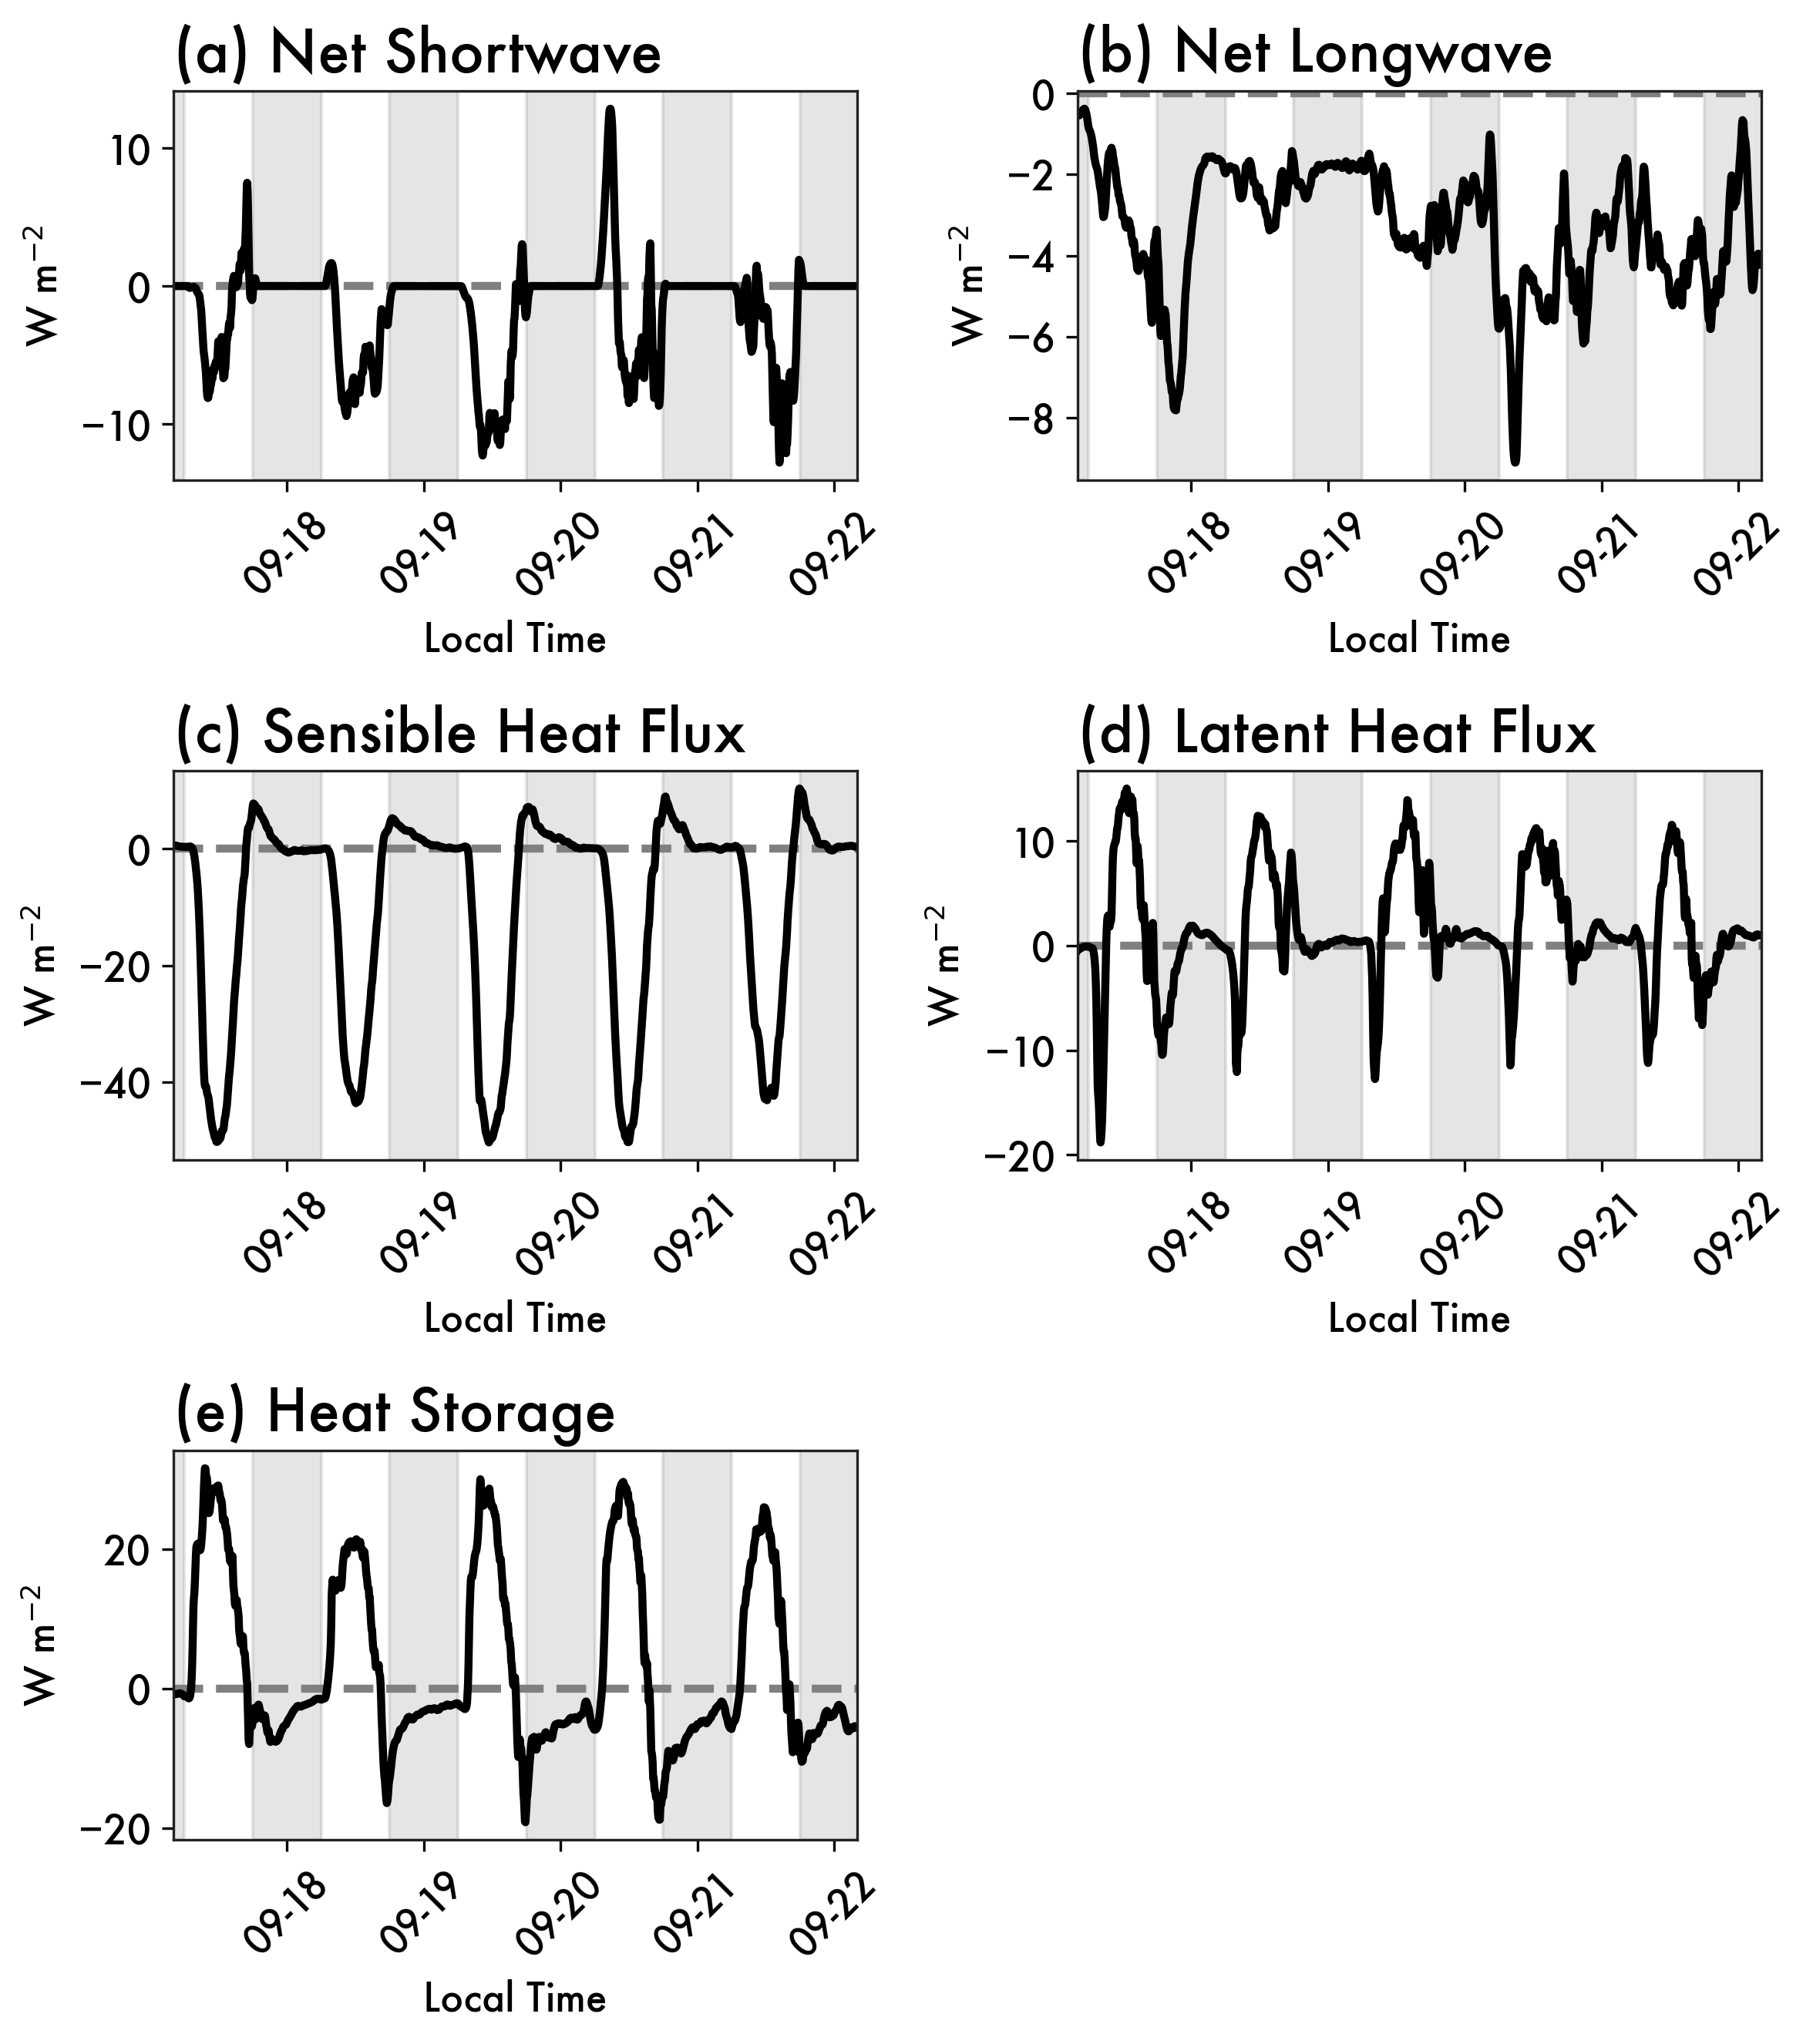

In [68]:
fig,axes=plt.subplots(3,2,figsize=(8,9))
axes = axes.flatten()

past = xr.open_dataset(f"{anaPath}/timeseries_land_lc1960.h5")
pres = xr.open_dataset(f"{anaPath}/timeseries_land_lc2019.h5")


for ax, var in zip(axes, ['swnet','lwnet','shf','lhf','g']):
    ax.plot(past.local_time,pres[var] - past[var],color='black')

    ax.axhline(0, ls="--", color="gray", zorder=0)


for ax, title in zip(axes, ['(a) Net Shortwave','(b) Net Longwave','(c) Sensible Heat Flux','(d) Latent Heat Flux','(e) Heat Storage']):
    ax.set_title(title)
    ax.set_ylabel('W m$^{-2}$')
    ax.set_xlabel('Local Time')
    ax.tick_params(axis="x", labelrotation=45)

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

    for d in ['2019-09-16',"2019-09-17", "2019-09-18", "2019-09-19", "2019-09-20",'2019-09-21']:
        ax.axvspan(
            pd.to_datetime(f"{d} 18:00"),
            pd.to_datetime(f"{d} 06:00")+dt.timedelta(days=1),
            zorder=0,
            color="gray",
            alpha=0.2,
        )

    ax.set_xlim(pd.to_datetime('2019-09-17 04:00'),pd.to_datetime('2019-09-22 04:00'))

axes[-1].axis("off")

handles, labels = axes[-2].get_legend_handles_labels()
fig.legend(handles, labels,bbox_to_anchor=(0.85,0.245))

plt.savefig(f"{figPath}/seb_timeseries_all_diff.pdf")
plt.show()
plt.close('all')

## Diurnal Cycle

### Multi-panel

lc1960
lc2019


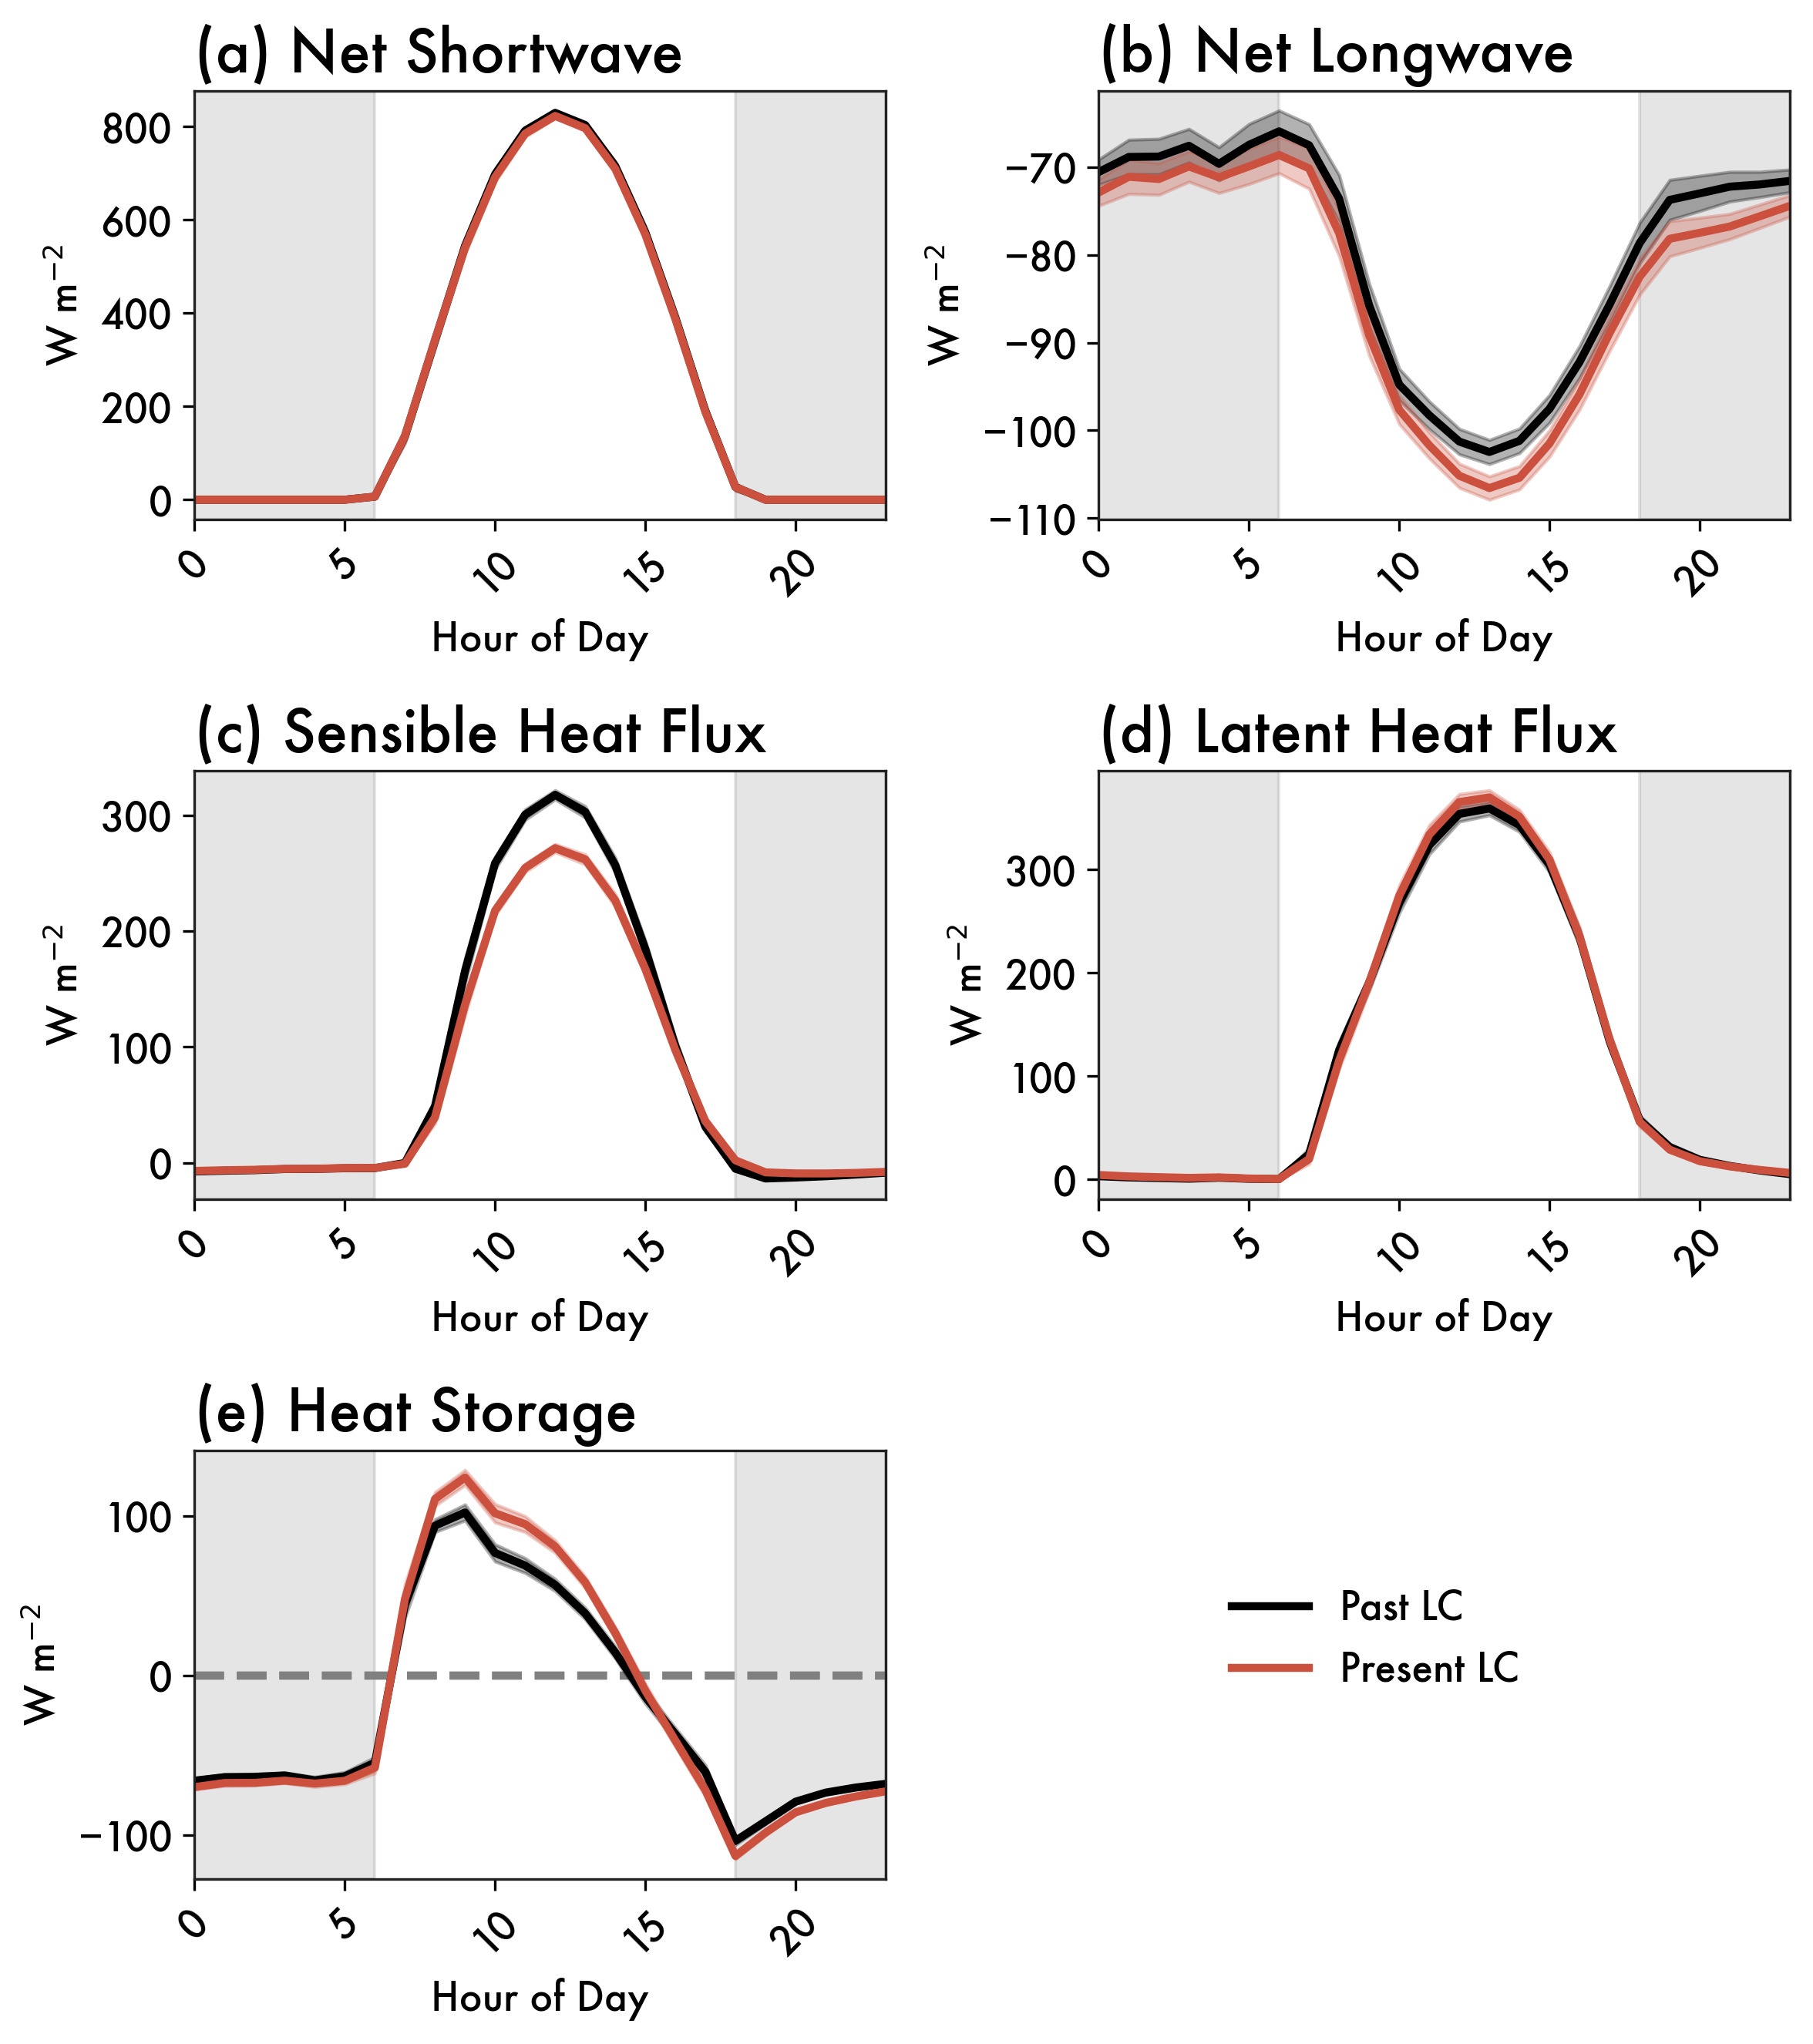

In [14]:
fig,axes=plt.subplots(3,2,figsize=(8,9))
axes = axes.flatten()


for run,col,lab in zip(runs,['black',red],["Past LC","Present LC"]):
    print(run)
    seb = xr.open_dataset(f"{anaPath}/diurn_land_{run}.h5")
    stde = xr.open_dataset(f"{anaPath}/diurn_stde_land_{run}.h5")

    for ax, var in zip(axes, ['swnet','lwnet','shf','lhf','g']):
        ax.plot(seb.hour,seb[var],color=col,label=lab)
        ax.fill_between(seb.hour,seb[var]-stde[var],seb[var]+stde[var],color=col,alpha=0.3)

        if var == "g":
            ax.axhline(0, ls="--", color="gray", zorder=0)

    seb.close()

for ax, title in zip(axes, ['(a) Net Shortwave','(b) Net Longwave','(c) Sensible Heat Flux','(d) Latent Heat Flux','(e) Heat Storage']):
    ax.set_title(title)
    ax.set_ylabel('W m$^{-2}$')
    ax.set_xlabel('Hour of Day')
    ax.tick_params(axis="x", labelrotation=45)


    ax.axvspan(0,6,
            zorder=0,
            color="gray",
            alpha=0.2,
    )
    ax.axvspan(18,23,
            zorder=0,
            color="gray",
            alpha=0.2,
    )

    ax.set_xlim(0,23)


axes[-1].axis("off")

handles, labels = axes[-2].get_legend_handles_labels()
fig.legend(handles, labels,bbox_to_anchor=(0.85,0.245))

plt.savefig(f"{figPath}/seb_diurnal_all.pdf")
plt.show()
plt.close('all')

###  Differences

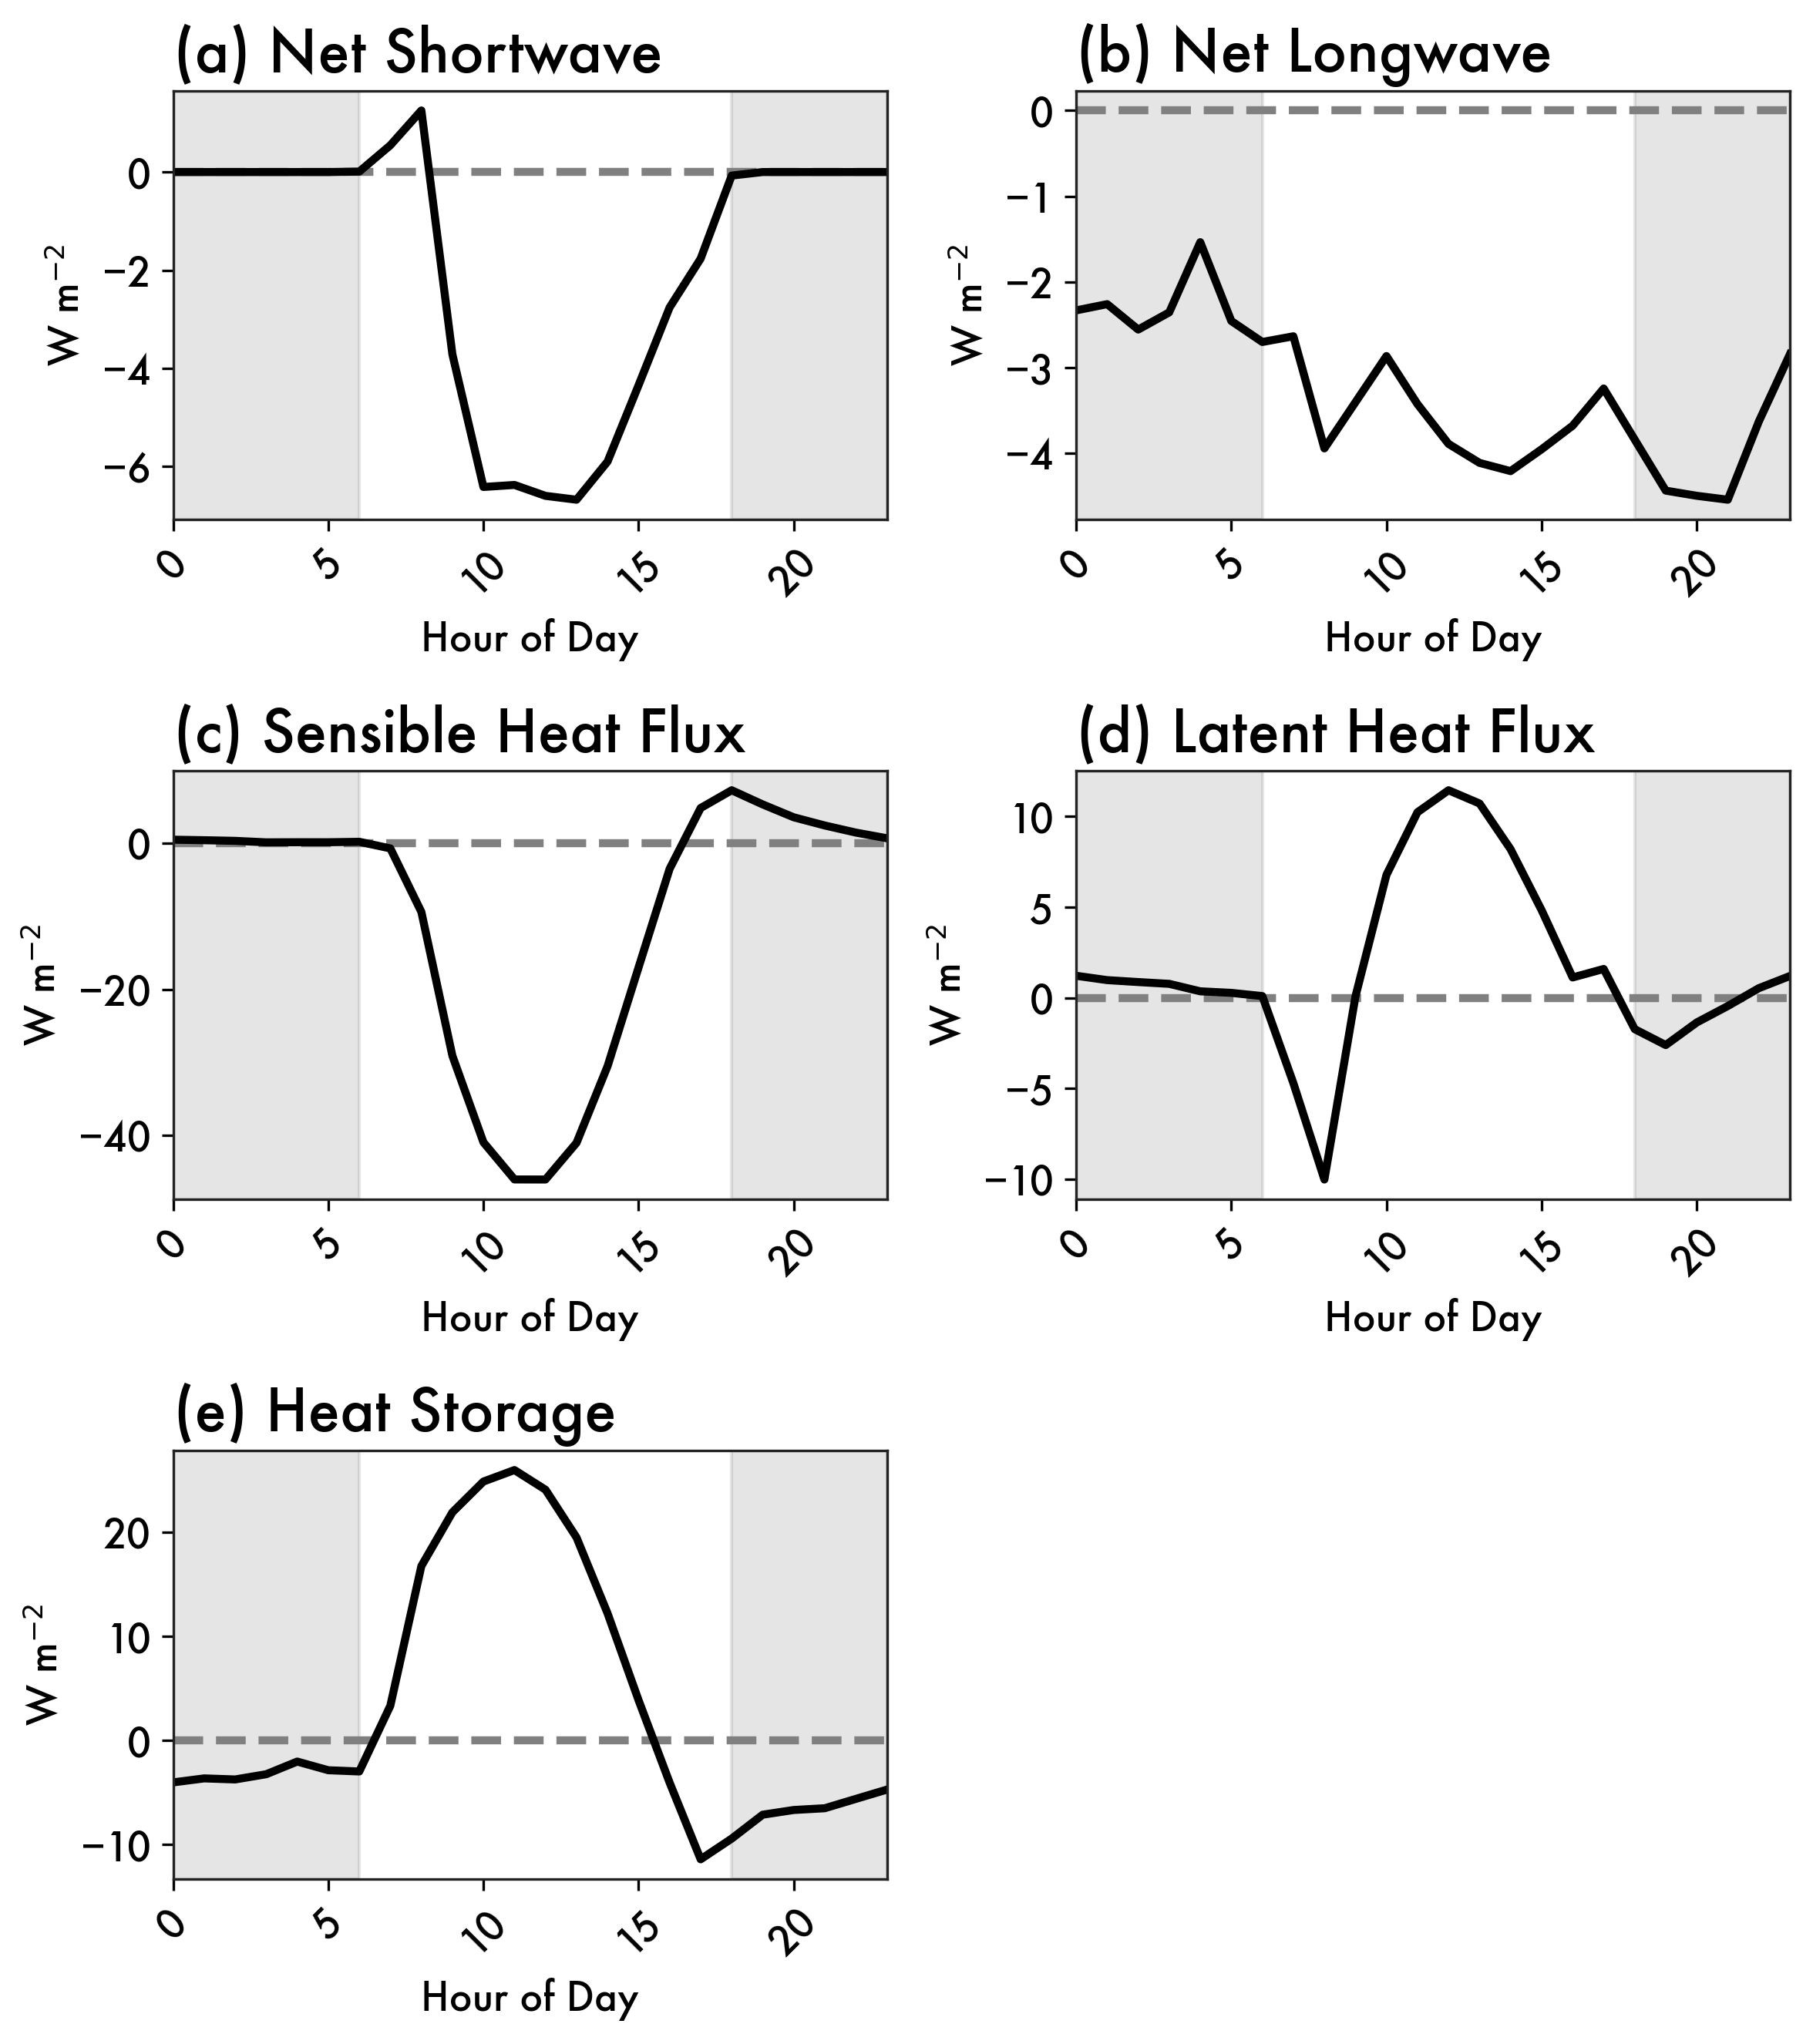

In [15]:
fig,axes=plt.subplots(3,2,figsize=(8,9))
axes = axes.flatten()

past = xr.open_dataset(f"{anaPath}/diurn_land_lc1960.h5")
pres = xr.open_dataset(f"{anaPath}/diurn_land_lc2019.h5")

for ax, var in zip(axes, ['swnet','lwnet','shf','lhf','g']):
    ax.plot(past.hour,pres[var]-past[var],color='black')

    ax.axhline(0, ls="--", color="gray", zorder=0)


for ax, title in zip(axes, ['(a) Net Shortwave','(b) Net Longwave','(c) Sensible Heat Flux','(d) Latent Heat Flux','(e) Heat Storage']):
    ax.set_title(title)
    ax.set_ylabel('W m$^{-2}$')
    ax.set_xlabel('Hour of Day')
    ax.tick_params(axis="x", labelrotation=45)


    ax.axvspan(0,6,
            zorder=0,
            color="gray",
            alpha=0.2,
    )
    ax.axvspan(18,23,
            zorder=0,
            color="gray",
            alpha=0.2,
    )

    ax.set_xlim(0,23)


axes[-1].axis("off")

handles, labels = axes[-2].get_legend_handles_labels()
fig.legend(handles, labels,bbox_to_anchor=(0.85,0.245))

plt.savefig(f"{figPath}/seb_diurnal_all_diff.pdf")
plt.show()
plt.close('all')

### Single Plot

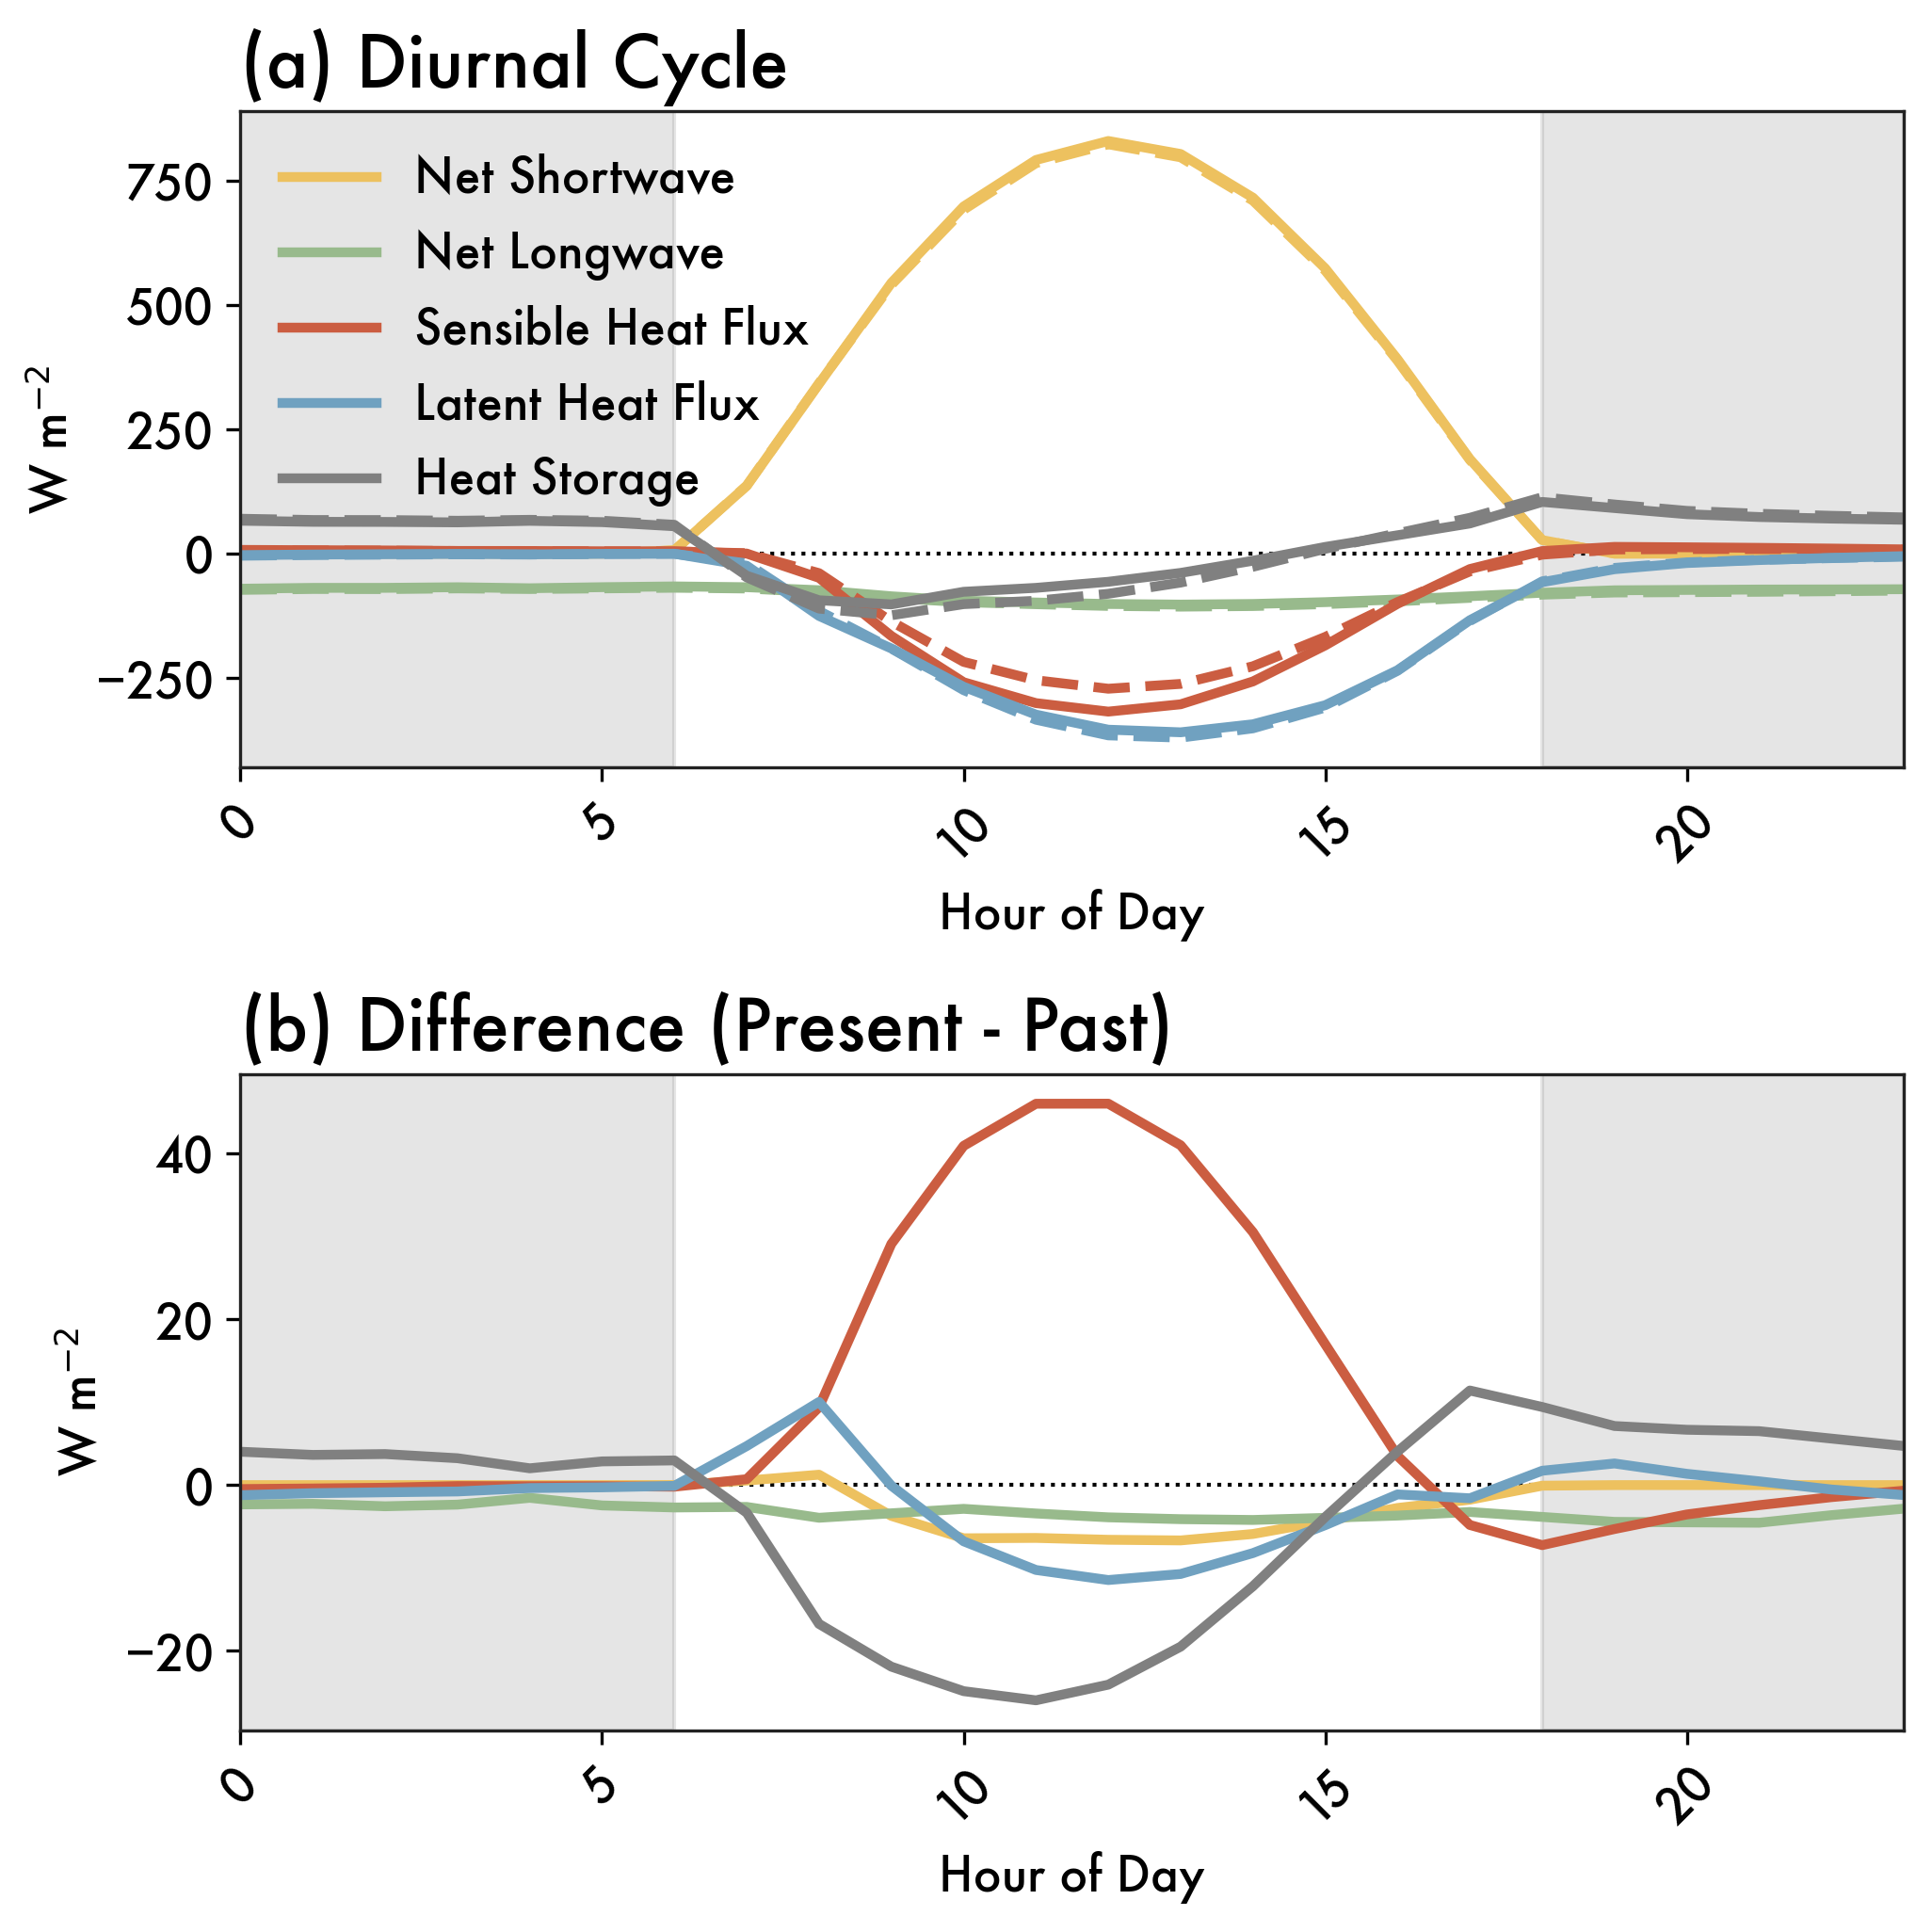

In [16]:
fig,axes=plt.subplots(2,1,figsize=(7,7))
axes = axes.flatten()

past = xr.open_dataset(f"{anaPath}/diurn_land_lc1960.h5")
pres = xr.open_dataset(f"{anaPath}/diurn_land_lc2019.h5")

for var,col,lab in zip(['swnet','lwnet','shf','lhf','g'],
                         ['#edc15f','#98ba8c','#CB5D41','#70A1C0','gray'],
                         ['Net Shortwave','Net Longwave','Sensible Heat Flux','Latent Heat Flux','Heat Storage']):
    for run, ls in zip([past,pres],['-','--']):
        if var in ['shf','lhf','g']:
            run[var] = -run[var]

        if ls == '--':
            lab = None

        axes[0].plot(run.hour,run[var],color=col,ls=ls,label=lab)

    axes[1].plot(run.hour,pres[var]-past[var],color=col)

for ax in axes:
    ax.set_ylabel('W m$^{-2}$')
    ax.set_xlabel('Hour of Day')
    ax.tick_params(axis="x", labelrotation=45)

    ax.axvspan(0,6,
            zorder=0,
            color="gray",
            alpha=0.2,
    )
    ax.axvspan(18,23,
            zorder=0,
            color="gray",
            alpha=0.2,
    )

    ax.set_xlim(0,23)
    ax.axhline(0, zorder=0, lw=1, ls=":", color="black")
    
axes[0].set_title('(a) Diurnal Cycle')
axes[1].set_title('(b) Difference (Present - Past)')

axes[0].legend(loc='upper left')

plt.savefig(f"{figPath}/seb_diurnal_combined.pdf")
plt.show()
plt.close('all')

Note sign convention here:

In panel a, positive numbers are terms that tend to heat up the surface (e.g., surface is being warmed by SW), while negative numbers are those which take energy from the surface (e.g., cooling a little through LW, mostly ting heat through heat fluxes + removing heat from the surface layer into the ground as heat storage)

In panel b, positive numbers are terms which contribute to more surface heating (i.e., less surface cooling) while negative numbers are terms which contribute to less surface heating (i.e., more surface cooling)